# **Tutorial 3** $\cdot$ Counterfactual Explanations

> **Abstract.** This tutorial introduces counterfactual explanations for molecular property prediction — methods that identify minimal structural modifications to change a model's prediction, rather than highlighting important features. We demonstrate two approaches using a Graph Neural Network trained on the AqSolDB water solubility dataset: the sampling-based MMACE method (via the `exmol` package) which explores chemical space broadly using the STONED algorithm, and exhaustive enumeration (via `vgd_counterfactuals`) which guarantees finding the optimal single-edit modification. The tutorial compares both methods on the same target molecule, illustrating their complementary strengths for understanding structure-property relationships.


**💾 Dataset.** This notebook will make use of the [AqSolDB](https://www.kaggle.com/datasets/sorkun/aqsoldb-a-curated-aqueous-solubility-dataset) 
dataset introduced by [Sorkun et al.](https://www.nature.com/articles/s41597-019-0151-1). It is a curated dataset consisting of roughly ten thousand 
small molecules annotated with experimentally determined [water solubility](https://en.wikipedia.org/wiki/Solubility) values. These target annotations were curated and consolidated from 
various sources throughout the literature. Due to its experimental nature and the presence of measurement noise, it is important to note that 
it is impossible to achieve perfect prediction accuracy for this dataset. Based on results from the literature, the practical limit to the 
performance likely is a predictivity (R² score) in the range between 0.86 and 0.89.

**📦 Packages.** Packages used in this notebook include:
- [RDKit](https://www.rdkit.org/docs/index.html) Cheminformatics framework for processing of SMILES strings and molecular manipulation.
- [Pandas](https://pandas.pydata.org/docs/index.html) for data representation and processing.
- [Pytorch](https://docs.pytorch.org/docs/stable/index.html) and [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) for the training of neural network models.
- [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) framework for the construction, training and explanation of graph neural network (GNN)-based property prediction models.
- [exmol](https://github.com/ur-whitelab/exmol) for generating counterfactual molecular explanations using the MMACE method.

In [1]:
import os
import random
import warnings

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import rdkit.Chem as Chem
import lightning.pytorch as pl
import torch.nn as nn
import torch.nn.functional as F
from rich.pretty import pprint
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torchmetrics import MeanSquaredError, R2Score

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from xai_chem_review import load_dataset_aqsoldb

The `load_dataset_aqsoldb` function loads and returns the AqSolDB dataset into a pandas `DataFrame` object. Each molecule is represented as a [SMILES](https://en.wikipedia.org/wiki/Simplified_Molecular_Input_Line_Entry_System) string with a continuous water solubility value (logS).

In [2]:
data_frame: pd.DataFrame = load_dataset_aqsoldb()
print(f'Loaded dataset with {data_frame.shape[0]} rows')
print(f'Solubility statistics:')
print(data_frame['solubility'].describe())
data_frame.head()

Loaded dataset with 11024 rows
Solubility statistics:
count    11024.000000
mean        -2.880460
std          2.343010
min        -13.171900
25%         -4.286934
50%         -2.600300
75%         -1.228457
max          2.137682
Name: solubility, dtype: float64


,index,ID,smiles,InChIKey,solubility,split
0,0,A-10,Cc1cccc(C=C)c1,JZHGRUMIRATHIU-UHFFFAOYSA-N,-3.123150,1
1,1,A-100,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,ODJUOZPKKHIEOZ-UHFFFAOYSA-N,-4.952869,1
2,2,A-1000,O=C1CCCCCCCCCOCCCCCO1,MKEIDVFLAWJKMY-UHFFFAOYSA-N,-3.883849,1
3,3,A-1002,CCCCCCCCCCC(C)CCCCCCCC,FFVPRSKCTDQLBP-UHFFFAOYSA-N,-6.451105,1
4,4,A-1003,NC(=O)N=NC(N)=O,XOZUGNYVDXMRKW-UHFFFAOYSA-N,-3.546243,1


In [3]:
data_frame['mol'] = data_frame['smiles'].apply(Chem.MolFromSmiles)
data_frame = data_frame.dropna(subset=['mol']).reset_index(drop=True)
print(f'After mol conversion {data_frame.shape[0]} rows remaining')

After mol conversion 11022 rows remaining


## **3.1** $\cdot$ 💡 Counterfactual Explanations

The previous tutorials have introduced *attributional* explanation methods &mdash; techniques that reveal which parts of the input are most important for a model's prediction. While these methods answer the question "what did the model focus on?", they don't directly address a more intuitive question that practitioners often ask: "what would need to change to get a different prediction?"

*Counterfactual explanations* answer exactly this question. Rather than highlighting important features or substructures, counterfactual methods identify the minimal modifications to an input that would change the model's prediction to a desired outcome. In other words, they provide "what-if" scenarios that reveal the decision boundaries learned by the model. This paradigm shift from attribution to intervention offers a fundamentally different perspective on model interpretability.

**Relevance to Molecular Property Prediction.** In the context of drug discovery and molecular design, counterfactual explanations are particularly valuable. When a model predicts that a compound has poor water solubility, a counterfactual explanation would show the smallest structural modifications that would improve the predicted solubility. Unlike attributional methods that might highlight "the aromatic ring is important", counterfactuals provide *actionable* insights like "replacing this methyl group with a hydroxyl group would increase solubility by 1.5 logS units". This makes counterfactual explanations directly applicable to lead optimization and molecular design workflows.

**Comparison to Attributional Methods.** The key distinction between counterfactual and attributional explanations lies in their output format and intended use:

- **Attributional methods** (SHAP, LIME, GNNExplainer) produce importance scores over input features or substructures, answering "what matters?"
- **Counterfactual methods** produce alternative molecular structures with different predictions, answering "what would need to change?"

Both approaches are complementary. Attributional explanations help understand the model's reasoning process, while counterfactuals provide concrete suggestions for molecular modifications. In practice, the structural changes suggested by counterfactuals often align with the features identified as important by attributional methods &mdash; but presented in a more directly actionable format.

**Challenges in Molecular Counterfactuals.** Generating counterfactual explanations for molecules presents unique challenges compared to tabular or image data. The modifications must produce *chemically valid* structures that respect valence rules, aromaticity constraints, and synthetic accessibility. Simply perturbing input features (as one might do with tabular data) is not sufficient &mdash; the resulting molecules must be realistic compounds that could potentially be synthesized and tested. This requirement has led to the development of specialized algorithms for exploring chemical space around a given molecule.

## **3.2** $\cdot$ 📚 *Molecular Model Agnostic Counterfactual Explanations* (`MMACE`)

The first example method from the literature is the *Molecular Model Agnostic Counterfactual Explanations (MMACE)* approach, implemented in the [exmol](https://github.com/ur-whitelab/exmol) package by [Wellawatte et al.](https://doi.org/10.1039/D1SC05259D). This method leverages the **STONED** (Superfast Traversal, Optimization, Novelty, Exploration and Discovery) algorithm to explore the chemical space around a given molecule by making random mutations to its SELFIES string representation, then identifies counterfactual examples among the generated variants.

**Core Methodology.** MMACE works by:
1. **Molecular Transformation**: Using STONED to generate chemically valid variants by randomly mutating, inserting, and deleting tokens in the molecule's SELFIES string representation (SELFIES are designed so that almost any such edit still decodes to a valid molecule)
2. **Model Evaluation**: Testing each generated variant with the target model to identify those with different predictions
3. **Similarity Ranking**: Ranking the counterfactual candidates by their structural similarity to the original molecule
4. **Selection**: Choosing the most similar counterfactuals that achieve the desired prediction change

**Implementation.** The `exmol` package provides a streamlined interface for generating molecular counterfactuals. The package is model-agnostic, meaning it can work with any molecular property prediction model that accepts SMILES strings as input and returns predictions. This flexibility makes it applicable to a wide range of machine learning models, from simple linear classifiers to complex neural networks.

### Graph Neural Network Model

Before generating counterfactual explanations, we need to train a molecular property prediction model. For this tutorial, we'll use a Graph Neural Network (GNN) to predict water solubility directly from molecular graph structures. This approach allows us to demonstrate how counterfactual explanations can be applied to sophisticated graph-based models for regression tasks.

We'll reuse the graph processing functions from the second tutorial, which convert molecules into graph representations suitable for GNN training. This approach provides direct access to molecular structure information, making it particularly suitable for understanding structural changes in counterfactual explanations for solubility prediction.

In [4]:
# --- Atom and Bond Encoding Functions ---
# These functions convert RDKit atom and bond objects into fixed-size numeric vectors
# suitable for use as node and edge features in a graph neural network.

def encode_atom(atom: Chem.Atom,
                supported_atoms: list[str] = ['C', 'N', 'O', 'S', 'P', 'Cl', 'Br', 'F'],
                ) -> np.ndarray:
    """
    Encodes a given RDKit atom object into a fixed-size vector representation of its properties,
    including a one-hot encoding of the atom type, valence information, and formal charge.

    :param atom: The RDKit Atom object to be converted.
    :param supported_atoms: A list of atom symbols supported for one-hot encoding. Atoms not
        in this list are marked as unknown.

    :returns: A numpy array of shape (n_features,) containing the encoded atom properties.
    """
    # One-hot encoding of atom type
    atom_one_hot = np.zeros(len(supported_atoms), dtype=np.float32)
    if atom.GetSymbol() in supported_atoms:
        atom_one_hot[supported_atoms.index(atom.GetSymbol())] = 1.0

    atom_unknown = float(atom.GetSymbol() not in supported_atoms)
    atom_valence = atom.GetTotalValence()
    atom_valence_implicit = atom.GetImplicitValence()
    atom_charge = atom.GetFormalCharge()

    return np.array([
        *atom_one_hot,
        atom_unknown,
        atom_valence,
        atom_valence_implicit,
        atom_charge,
    ], dtype=np.float32)


def encode_bond(bond: Chem.Bond,
                supported_bond_types: list[int] = [
                    Chem.BondType.SINGLE,
                    Chem.BondType.DOUBLE,
                    Chem.BondType.TRIPLE,
                ],
                ) -> np.ndarray:
    """
    Encodes a given RDKit bond object into a fixed-size vector representation of its properties,
    including a one-hot encoding of the bond type, stereo configuration, and aromaticity.

    :param bond: The RDKit Bond object to be converted.
    :param supported_bond_types: A list of bond types supported for one-hot encoding.

    :returns: A numpy array of shape (n_features,) containing the encoded bond properties.
    """
    # One-hot encoding of bond type
    bond_type_one_hot = np.zeros(len(supported_bond_types), dtype=np.float32)
    if bond.GetBondType() in supported_bond_types:
        bond_type_one_hot[supported_bond_types.index(bond.GetBondType())] = 1.0

    bond_unknown = float(bond.GetBondType() not in supported_bond_types)
    bond_stereo = bond.GetStereo()
    bond_aromatic = float(bond.GetIsAromatic())

    return np.array([
        *bond_type_one_hot,
        bond_unknown,
        bond_stereo,
        bond_aromatic,
    ], dtype=np.float32)


# --- Graph Conversion Functions ---
# These functions handle the conversion between SMILES strings, networkx graphs,
# and PyTorch Geometric Data objects.

def graph_from_smiles(smiles: str,
                      atom_encoder: callable = encode_atom,
                      bond_encoder: callable = encode_bond,
                      ) -> nx.Graph:
    """
    Converts a SMILES string to a networkx Graph representation where nodes represent
    atoms and edges represent bonds, each annotated with numeric feature vectors.

    :param smiles: The SMILES string of the molecule to be converted.
    :param atom_encoder: A callable that encodes an RDKit Atom into a feature vector.
    :param bond_encoder: A callable that encodes an RDKit Bond into a feature vector.

    :returns: A networkx Graph object, or None if the SMILES string is invalid.
    """
    mol: Chem.Mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    g: nx.Graph = nx.Graph()

    # Add atoms as nodes with encoded features
    for atom in mol.GetAtoms():
        node_attributes: np.ndarray = atom_encoder(atom)
        g.add_node(
            atom.GetIdx(),
            node_index=atom.GetIdx(),
            node_atom=atom.GetSymbol(),
            node_attributes=node_attributes
        )

    # Add bonds as edges with encoded features
    for bond in mol.GetBonds():
        edge_attributes: np.ndarray = bond_encoder(bond)
        g.add_edge(
            bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(),
            edge_type=bond.GetBondType(),
            edge_attributes=edge_attributes,
        )

    return g


def data_from_graph(graph: nx.Graph) -> Data:
    """
    Converts a networkx Graph to a PyTorch Geometric Data object suitable for GNN training.

    :param graph: A networkx Graph with 'node_attributes' and 'edge_attributes' annotations.

    :returns: A PyTorch Geometric Data object, or None if the input graph is None.
    """
    if graph is None:
        return None

    # Extract node features
    node_attributes = np.array([
        data['node_attributes'].tolist() for _, data in graph.nodes(data=True)
    ])

    # Extract edge indices and features
    edge_indices = np.array([
        (u, v) for (u, v) in graph.edges()
    ])
    edge_attributes = np.array([
        data['edge_attributes'].tolist()
        for _, _, data in graph.edges(data=True)
    ])

    # Construct the Data object
    data = Data(
        x=torch.tensor(node_attributes, dtype=torch.float32),
        edge_index=torch.tensor(edge_indices.T, dtype=torch.long) if len(edge_indices) > 0 else torch.empty((2, 0), dtype=torch.long),
        edge_attr=torch.tensor(edge_attributes, dtype=torch.float32) if len(edge_attributes) > 0 else torch.empty((0, 6), dtype=torch.float32),
    )

    # Attach target labels if present in the graph
    if graph.graph.get('graph_labels') is not None:
        data.y = torch.tensor(graph.graph['graph_labels'], dtype=torch.float32)

    return data


# --- Example usage ---

test_smiles = 'CCc1ccc2nc(S(N)(=O)=O)sc2c1'
test_graph = graph_from_smiles(test_smiles)
test_data = data_from_graph(test_graph)
print(f'Test molecule converted to graph with {test_data.x.shape[0]} nodes and {test_data.edge_index.shape[1]} edges')

Test molecule converted to graph with 15 nodes and 16 edges


Now we can convert all molecules in our dataset to graph representations and prepare them for GNN training:

In [5]:
# --- Converting molecules to graph representations ---
# Apply the graph_from_smiles function to each molecule in the dataset.

data_frame['graph'] = data_frame['smiles'].apply(graph_from_smiles)

# Remove molecules that couldn't be converted to valid graphs
data_frame = data_frame.dropna(subset=['graph']).reset_index(drop=True)

# --- Attaching target labels to graphs ---
# The target solubility values need to be attached to the graph objects for PyG Data conversion.

for idx, row in data_frame.iterrows():
    if row['graph'] is not None:
        row['graph'].graph['graph_labels'] = row['solubility']

print(f'Dataset after graph conversion: {len(data_frame)} molecules')
data_frame[['smiles', 'solubility']].head()

Dataset after graph conversion: 11022 molecules


,smiles,solubility
0,Cc1cccc(C=C)c1,-3.123150
1,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,-4.952869
2,O=C1CCCCCCCCCOCCCCCO1,-3.883849
3,CCCCCCCCCCC(C)CCCCCCCC,-6.451105
4,NC(=O)N=NC(N)=O,-3.546243


### Model Training

Next, we'll train a Graph Neural Network regressor to predict water solubility based on molecular graph structure. This model will serve as our "black-box" predictor for which we'll generate counterfactual explanations.

In [6]:
# --- Train-test split ---
# Randomly partition the dataset into training and test sets using an 80/20 split.

indices = list(range(len(data_frame)))
random.shuffle(indices)

n_train = int(0.8 * len(indices))
train_indices = indices[:n_train]
test_indices = indices[n_train:]

print(f'Train set: {len(train_indices)} molecules')
print(f'Test set: {len(test_indices)} molecules')

# --- Creating PyTorch Geometric Data objects ---

data_list_train = [
    data_from_graph(data_frame.iloc[idx]['graph'])
    for idx in train_indices
    if data_frame.iloc[idx]['graph'] is not None
]
data_list_test = [
    data_from_graph(data_frame.iloc[idx]['graph'])
    for idx in test_indices
    if data_frame.iloc[idx]['graph'] is not None
]

# --- Creating DataLoaders ---

loader_train = DataLoader(data_list_train, batch_size=32, shuffle=True, num_workers=4)
loader_test = DataLoader(data_list_test, batch_size=32, shuffle=False)

Train set: 8817 molecules
Test set: 2205 molecules


In [7]:
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import SumAggregation


class SolubilityGNN(pl.LightningModule):
    """
    Graph Neural Network regressor for predicting water solubility from molecular graphs.
    Uses GINE (Graph Isomorphism Network with Edge features) convolutional layers followed
    by global sum pooling and dense layers for graph-level regression.
    
    :param input_dim: The number of input node features.
    :param edge_dim: The number of input edge features.
    :param hidden_units: List of hidden layer sizes for the graph convolutions.
    :param dense_units: List of hidden layer sizes for the dense prediction network.
    :param output_dim: The number of output features (1 for single-target regression).
    :param learning_rate: Learning rate for the Adam optimizer.
    """
    
    def __init__(self, 
                 input_dim: int,
                 edge_dim: int,
                 hidden_units: list[int] = [128, 128, 128],
                 dense_units: list[int] = [64, 32],
                 output_dim: int = 1,
                 learning_rate: float = 1e-4,
                 ):
        super().__init__()
        self.save_hyperparameters()
        
        self.input_dim = input_dim
        self.edge_dim = edge_dim
        self.hidden_units = hidden_units
        self.dense_units = dense_units
        self.output_dim = output_dim
        self.learning_rate = learning_rate
        
        # --- Embedding layers ---
        # Map input features to the hidden dimension
        self.node_embedding = nn.Linear(input_dim, hidden_units[0])
        self.edge_embedding = nn.Linear(edge_dim, 64)
        
        # --- Graph convolutional layers ---
        # Build GINE layers with internal MLPs for message passing
        self.conv_layers = nn.ModuleList()
        prev_units = hidden_units[0]
        for units in hidden_units:
            mlp = nn.Sequential(
                nn.Linear(prev_units, units),
                nn.BatchNorm1d(units),
                nn.ReLU(),
                nn.Linear(units, units),
                nn.BatchNorm1d(units),
                nn.ReLU()
            )
            conv = GINEConv(nn=mlp, edge_dim=64)
            self.conv_layers.append(conv)
            prev_units = units
            
        # --- Global pooling ---
        self.pooling = SumAggregation()
        
        # --- Dense prediction layers ---
        self.dense_layers = nn.ModuleList()
        for units in dense_units:
            layer = nn.Sequential(
                nn.Linear(prev_units, units),
                nn.BatchNorm1d(units),
                nn.ReLU()
            )
            self.dense_layers.append(layer)
            prev_units = units
            
        self.output_layer = nn.Linear(prev_units, output_dim)
        
        # --- Loss and metrics ---
        self.criterion = nn.MSELoss()
        self.mse = MeanSquaredError()
        self.r2 = R2Score()
        
    def forward(self, x, edge_index, edge_attr, batch):
        """
        Forward pass through the GNN.
        
        :param x: Node feature tensor of shape (num_nodes, input_dim).
        :param edge_index: Edge index tensor of shape (2, num_edges).
        :param edge_attr: Edge attribute tensor of shape (num_edges, edge_dim).
        :param batch: Batch assignment tensor for graph-level pooling.
        
        :returns: Prediction tensor of shape (batch_size, output_dim).
        """
        # Embed node and edge features
        node_emb = self.node_embedding(x)
        edge_emb = self.edge_embedding(edge_attr)
        
        # Apply graph convolutions
        for conv in self.conv_layers:
            node_emb = conv(node_emb, edge_index, edge_emb)
            
        # Aggregate node embeddings to graph-level representation
        graph_emb = self.pooling(node_emb, batch)
        
        # Apply dense prediction layers
        output = graph_emb
        for dense in self.dense_layers:
            output = dense(output)
            
        output = self.output_layer(output)
        return output
    
    def predict_smiles(self, smiles: str) -> float:
        """
        Predict solubility for a single SMILES string.
        
        :param smiles: The SMILES string of the molecule.
        
        :returns: Predicted solubility value (logS).
        """
        graph = graph_from_smiles(smiles)
        if graph is None:
            return 0.0
            
        data = data_from_graph(graph)
        if data is None:
            return 0.0
            
        data.batch = torch.zeros(data.x.shape[0], dtype=torch.long)
        
        self.eval()
        with torch.no_grad():
            prediction = self.forward(data.x, data.edge_index, data.edge_attr, data.batch)
            return prediction.item()
    
    def predict_batch(self, smiles_list: list[str]) -> list[float]:
        """
        Predict solubility for a batch of SMILES strings.
        
        :param smiles_list: List of SMILES strings.
        
        :returns: List of predicted solubility values.
        """
        graphs = [graph_from_smiles(smiles) for smiles in smiles_list]
        data_list = [data_from_graph(g) for g in graphs if g is not None]
        
        if not data_list:
            return [0.0] * len(smiles_list)
        
        loader = DataLoader(data_list, batch_size=len(data_list), shuffle=False)
        batch = next(iter(loader))
        
        self.eval()
        with torch.no_grad():
            predictions = self.forward(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            predictions = predictions.squeeze()
            
        # Handle single prediction case
        if isinstance(predictions, torch.Tensor) and predictions.dim() == 0:
            predictions = [predictions.item()]
        else:
            predictions = predictions.tolist()
            
        # Fill results for all molecules (including invalid SMILES)
        results = []
        data_idx = 0
        for graph in graphs:
            if graph is not None:
                results.append(predictions[data_idx])
                data_idx += 1
            else:
                results.append(0.0)
                
        return results
    
    def training_step(self, batch, batch_idx):
        output = self.forward(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = self.criterion(output.squeeze(), batch.y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        output = self.forward(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = self.criterion(output.squeeze(), batch.y)
        self.mse.update(output.squeeze(), batch.y)
        self.r2.update(output.squeeze(), batch.y)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        return loss
    
    def on_validation_epoch_end(self):
        self.log('val_mse', self.mse.compute(), prog_bar=True)
        self.log('val_r2', self.r2.compute(), prog_bar=True)
        self.mse.reset()
        self.r2.reset()
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate, weight_decay=1e-5)


# --- Model instantiation ---

model = SolubilityGNN(
    input_dim=data_list_train[0].x.shape[1],
    edge_dim=data_list_train[0].edge_attr.shape[1],
    hidden_units=[128, 128, 128],
    dense_units=[64, 32],
    output_dim=1,
)

print(f'Model initialized with {data_list_train[0].x.shape[1]} node features and {data_list_train[0].edge_attr.shape[1]} edge features')

# Test prediction function
test_smiles = 'CCc1ccc2nc(S(N)(=O)=O)sc2c1'
test_prediction = model.predict_smiles(test_smiles)
print(f'Test prediction for {test_smiles}: {test_prediction:.3f} logS')

Model initialized with 12 node features and 6 edge features
Test prediction for CCc1ccc2nc(S(N)(=O)=O)sc2c1: -0.087 logS


In [8]:
from xai_chem_review.utils import PrintLossCallback

# --- Model training ---

trainer = pl.Trainer(
    max_epochs=30,
    accelerator='auto',
    enable_progress_bar=True,
    logger=False,
    callbacks=[
        PrintLossCallback(),
    ]
)

trainer.fit(
    model=model,
    train_dataloaders=loader_train,
    val_dataloaders=loader_test,
)

# Set model to evaluation mode for inference
model.eval()
print('Model training completed.')

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type             ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ node_embedding │ Linear           │  1.7 K │ eval │     0 │
│ 1 │ edge_embedding │ Linear           │    448 │ eval │     0 │
│ 2 │ conv_layers    │ ModuleList       │  125 K │ eval │     0 │
│ 3 │ pooling        │ SumAggregation   │      0 │ eval │     0 │
│ 4 │ dense_layers   │ ModuleList       │ 10.5 K │ eval │     0 │
│ 5 │ output_layer   │ Linear           │     33 │ eval │     0 │
│ 6 │ criterion      │ MSELoss          │      0 │ eval │     0 │
│ 7 │ mse            │ MeanSquaredError │      0 │ eval │     0 │
│ 8 │ r2             │ R2Score          │      0 │ eval │     0 │
└───┴────────────────┴──────────────────┴────────┴──────┴───────┘

...

Epoch 15 | train_loss: 2.8105 | val_loss: 2.8095

Epoch 20 | train_loss: 2.2937 | val_loss: 2.5143

Epoch 25 | train_loss: 1.8579 | val_loss: 2.0066

`Trainer.fit` stopped: `max_epochs=30` reached.


Model training completed.


In [17]:
# --- Evaluate the trained model on the held-out test set ---
# Compute R² and RMSE on the test split so we know how much to trust the model's
# predictions (and therefore its counterfactuals).

preds, targets = [], []
model.eval()
with torch.no_grad():
    for batch in loader_test:
        out = model.forward(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze()
        preds.append(out)
        targets.append(batch.y)

preds = torch.cat(preds)
targets = torch.cat(targets)

test_rmse = torch.sqrt(torch.mean((preds - targets) ** 2)).item()
ss_res = torch.sum((targets - preds) ** 2)
ss_tot = torch.sum((targets - targets.mean()) ** 2)
test_r2 = (1 - ss_res / ss_tot).item()

print(f'Held-out test set ({len(targets)} molecules):  R² = {test_r2:.3f}   RMSE = {test_rmse:.3f} logS')

Held-out test set (2205 molecules):  R² = 0.644   RMSE = 1.385 logS


**📝 A note on model quality.** This demonstration model is trained only briefly (30 epochs) and does not reach the ~0.86&ndash;0.89 R² practical ceiling noted in the introduction. Its prediction error (RMSE) is in fact comparable to the magnitude of many of the counterfactual &Delta;logS shifts we will see below. The specific shift values should therefore be read as *illustrative of the methods* &mdash; how counterfactuals are generated and compared &mdash; rather than as precise chemical effects. A better-fit model would generally yield larger and more chemically sensible shifts.

### Installing and Setting Up ExMol

Before we can generate counterfactual explanations, we need to install the `exmol` package. The package provides the MMACE implementation for molecular counterfactual generation.

**📝 Note.** The `exmol` package requires specific versions of RDKit and other dependencies. If you encounter installation issues, it may be necessary to create a separate python environment with compatible package versions.

In [9]:
import exmol

### Generating Counterfactual Explanations

Now we can use the trained model to generate counterfactual explanations using the MMACE method. The process involves:

1. **Selecting a target molecule** for explanation
2. **Sampling the chemical space** around the molecule using STONED
3. **Evaluating candidates** with our trained model
4. **Splitting candidates by direction** into solubility-*increasing* and solubility-*decreasing* counterfactuals
5. **Ranking each direction by similarity** to find the most similar counterfactuals in either direction

Treating the two directions separately mirrors the directional handling we apply to the exhaustive (VGD) method later on, and lets us compare both methods direction-by-direction.

In [10]:
# --- Define the target molecule for counterfactual analysis ---
# Change this SMILES string to analyze a different molecule.

TARGET_SMILES = 'CCCCCCCCCCCCCCC'  # Pentadecane (long alkane, low solubility)

# Validate the SMILES and compute initial prediction
mol = Chem.MolFromSmiles(TARGET_SMILES)
if mol is None:
    raise ValueError(f"Invalid SMILES string: {TARGET_SMILES}")

selected_molecule = TARGET_SMILES
selected_prediction = model.predict_smiles(TARGET_SMILES)

print('Target molecule for counterfactual analysis:')
print(f'  SMILES: {selected_molecule}')
print(f'  Predicted solubility: {selected_prediction:.3f} logS')
print(f'  Molecular formula: {Chem.rdMolDescriptors.CalcMolFormula(mol)}')

Target molecule for counterfactual analysis:
  SMILES: CCCCCCCCCCCCCCC
  Predicted solubility: -5.593 logS
  Molecular formula: C15H32


In [11]:
# --- Generate directional counterfactual explanations using ExMol ---
# We split the sampled chemical space into two directions:
#   * "increase" counterfactuals: variants that INCREASE the predicted solubility
#   * "decrease" counterfactuals: variants that DECREASE the predicted solubility
# This mirrors the directional treatment used for the exhaustive (VGD) method below
# and lets us compare the two methods direction-by-direction further down.

print(f'Generating counterfactual explanations for: {selected_molecule}')
print(f'Original prediction: {selected_prediction:.3f} logS')
print('This may take a few minutes...\n')

K_RESULTS = 10              # number of counterfactuals to keep per direction

# Minimum |delta logS| for a sample to count as a counterfactual. A lower bar surfaces more
# (and more marginal) counterfactuals -- useful here because the "decrease" direction for an
# already very insoluble molecule only offers small changes. Because each direction is ranked
# by *similarity* (not magnitude), a low threshold also lets very similar, small-change
# molecules dominate the top. Raise it (e.g. 1.0) to keep only clearly meaningful changes.
prediction_threshold = 0.2

mmace_increase = []
mmace_decrease = []

try:
    # --- Step 1: Sample the chemical space ---
    # The STONED algorithm generates chemically valid molecular variants by making random
    # mutations, insertions, and deletions to tokens of the molecule's SELFIES string
    # representation (almost any such edit still decodes to a valid molecule).

    print('Sampling chemical space with STONED algorithm...')

    def prediction_function(smiles_list):
        """
        Wrapper function for our model that matches exmol's expected interface.

        :param smiles_list: A single SMILES string or list of SMILES strings.

        :returns: Numpy array of predicted solubility values.
        """
        if isinstance(smiles_list, str):
            smiles_list = [smiles_list]
        predictions = model.predict_batch(smiles_list)
        return np.array(predictions)

    # Sample molecular space using ExMol (medium preset: up to 2 single-token SELFIES edits)
    samples = exmol.sample_space(
        selected_molecule,
        prediction_function,
        batched=True,
        num_samples=2000,
        preset='medium'
    )

    print(f'Generated {len(samples)} molecular variants')

    # --- Step 2: Split candidates into directional counterfactuals ---
    # A candidate counts as a counterfactual if its prediction differs from the original by at
    # least `prediction_threshold`. The sign of the change determines its direction:
    # positive -> more soluble ("increase"), negative -> less soluble ("decrease").

    print('Identifying directional counterfactual explanations...')

    for sample in samples:
        # Skip the origin molecule itself
        if getattr(sample, 'is_origin', False):
            continue

        change = sample.yhat - selected_prediction
        if change >= prediction_threshold:
            sample.prediction_change = change
            mmace_increase.append(sample)
        elif change <= -prediction_threshold:
            sample.prediction_change = change
            mmace_decrease.append(sample)

    # Within each direction, rank by structural similarity (most similar first) -- this is
    # MMACE's natural ranking: the closest molecule that still flips the prediction.
    mmace_increase = sorted(mmace_increase, key=lambda x: x.similarity, reverse=True)[:K_RESULTS]
    mmace_decrease = sorted(mmace_decrease, key=lambda x: x.similarity, reverse=True)[:K_RESULTS]

    print(f'Found {len(mmace_increase)} "increase" and {len(mmace_decrease)} "decrease" '
          f'counterfactuals with |delta logS| >= {prediction_threshold}')

except Exception as e:
    print(f'Error generating counterfactual explanations: {e}')
    import traceback
    traceback.print_exc()

Generating counterfactual explanations for: CCCCCCCCCCCCCCC
Original prediction: -5.593 logS
This may take a few minutes...

Sampling chemical space with STONED algorithm...


  0%|                                                                                                                                 | 0/2000 [00:00<?, ?it/s]

🥌STONED🥌 Mutations: 1:   0%|                                                                                                        | 0/2000 [00:00<?, ?it/s]

🥌STONED🥌 Mutations: 1:  50%|█████████████████████████████████████████████▌                                             | 1000/2000 [00:00<00:00, 2444.23it/s]

🥌STONED🥌 Mutations: 2:  50%|█████████████████████████████████████████████▌                                             | 1000/2000 [00:00<00:00, 2444.23it/s]

...

🔭Projecting...🔭:   0%|                                                                                                               | 0/557 [00:00<?, ?it/s]

🥰Finishing up🥰: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 557.0/557 [00:00<00:00, 4598.08it/s]

🤘Done🤘: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 557.0/557 [00:00<00:00, 4038.54it/s]

🤘Done🤘: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 557.0/557 [00:00<00:00, 3974.78it/s]

Generated 557 molecular variants
Identifying directional counterfactual explanations...
Found 10 "increase" and 6 "decrease" counterfactuals with |delta logS| >= 0.2


MMACE Counterfactual Analysis -- Increase (more soluble)
Original Molecule:
  SMILES: CCCCCCCCCCCCCCC
  Predicted solubility: -5.593 logS
  Formula: C15H32
  Weight: 212.42

Top Counterfactual Explanations:
----------------------------------------------------------------------

Counterfactual 1:
  SMILES: C(CCCCCCCCCCCC)C
  Solubility: -5.593 -> -5.102 logS (delta +0.491)
  Similarity: 0.930
  Formula: C14H30
  Weight: 198.4 (delta -14.0)
  Interpretation: more soluble

Counterfactual 2:
  SMILES: C(CCCCCCCCCCC)C
  Solubility: -5.593 -> -4.778 logS (delta +0.816)
  Similarity: 0.860
  Formula: C13H28
  Weight: 184.4 (delta -28.1)
  Interpretation: more soluble

Counterfactual 3:
  SMILES: OCCCCCCCCCCCCCC
  Solubility: -5.593 -> -4.010 logS (delta +1.583)
  Similarity: 0.792
  Formula: C14H30O
  Weight: 214.4 (delta +2.0)
  Interpretation: more soluble

Counterfactual 4:
  SMILES: C(CCCC)CCCCCCCCCF
  Solubility: -5.593 -> -5.293 logS (delta +0.300)
  Similarity: 0.792
  Formula: C14H29F

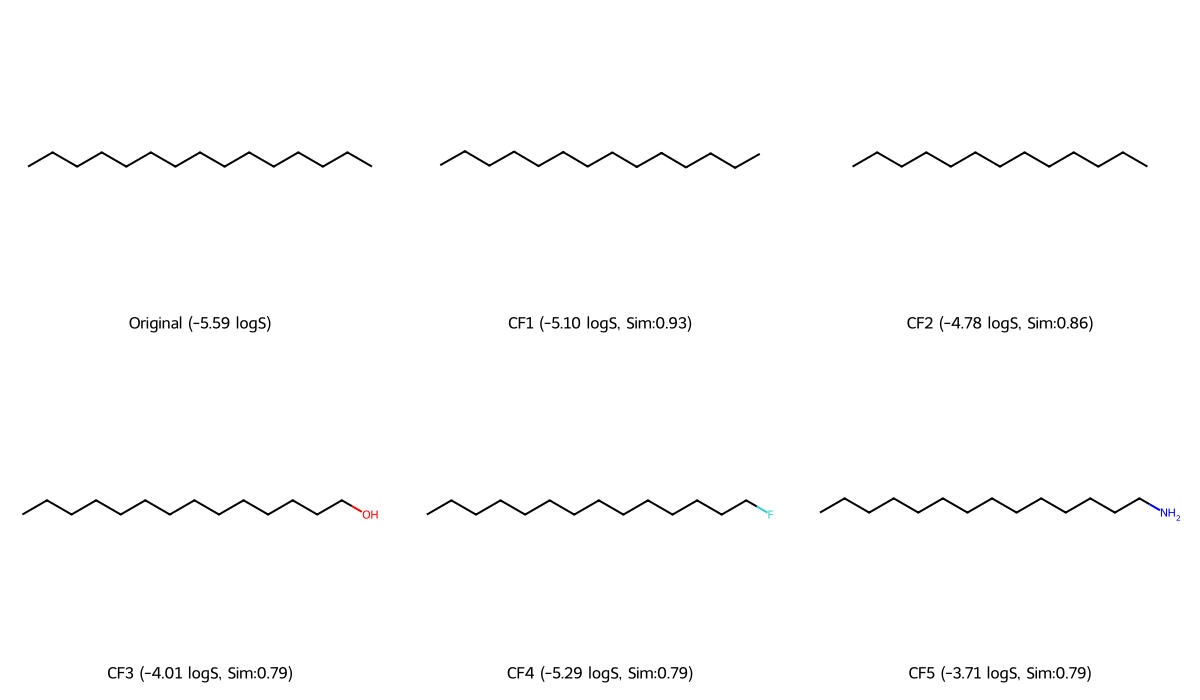


Summary Statistics:
  Counterfactuals found: 10
  Average similarity: 0.811 +/- 0.045
  Change range: +0.209 to +1.886 logS
  Average change: +0.873 logS

MMACE Counterfactual Analysis -- Decrease (less soluble)
Original Molecule:
  SMILES: CCCCCCCCCCCCCCC
  Predicted solubility: -5.593 logS
  Formula: C15H32
  Weight: 212.42

Top Counterfactual Explanations:
----------------------------------------------------------------------

Counterfactual 1:
  SMILES: ICCCCCCCCCCCCCC
  Solubility: -5.593 -> -6.355 logS (delta -0.762)
  Similarity: 0.792
  Formula: C14H29I
  Weight: 324.3 (delta +111.9)
  Interpretation: less soluble

Counterfactual 2:
  SMILES: C#CCCCCCCCCCCCCCCC
  Solubility: -5.593 -> -5.953 logS (delta -0.359)
  Similarity: 0.704
  Formula: C17H32
  Weight: 236.4 (delta +24.0)
  Interpretation: less soluble

Counterfactual 3:
  SMILES: C#SCCCCCCCCCCCCCCC
  Solubility: -5.593 -> -5.948 logS (delta -0.355)
  Similarity: 0.704
  Formula: C16H32S
  Weight: 256.5 (delta +44.1)
  I

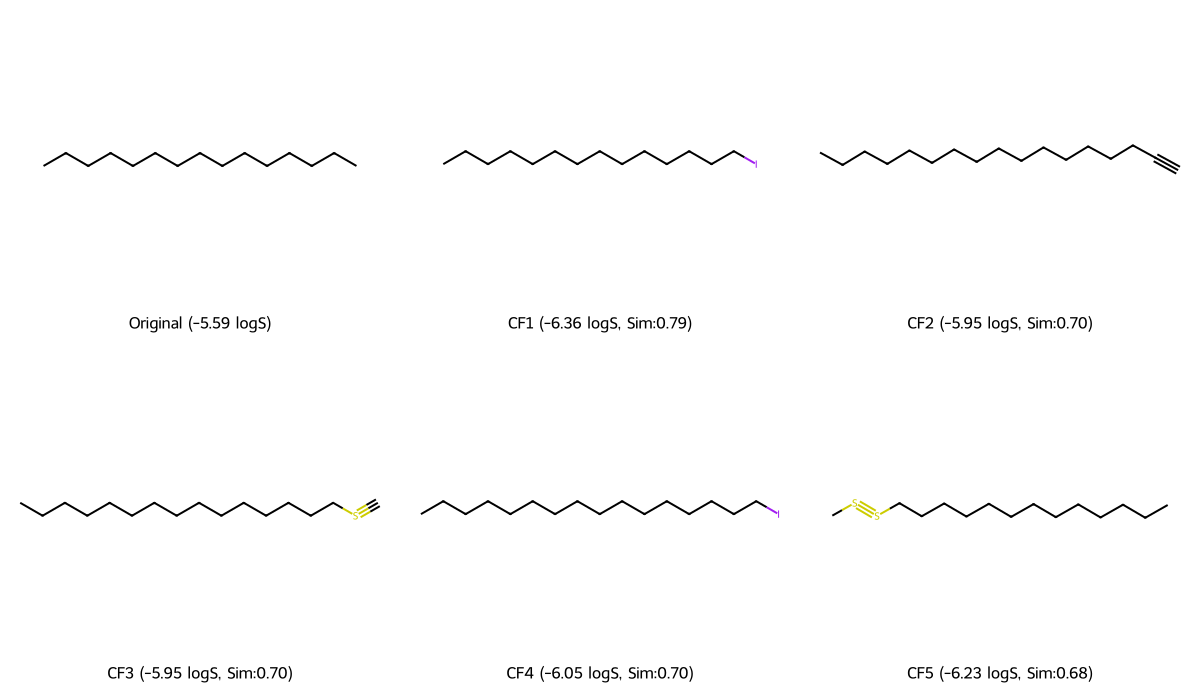


Summary Statistics:
  Counterfactuals found: 6
  Average similarity: 0.693 +/- 0.064
  Change range: -0.762 to -0.355 logS
  Average change: -0.531 logS



In [12]:
from rdkit.Chem import Draw, Descriptors
from IPython.display import display


# --- Visualization Helper Functions ---

def display_counterfactual_grid(original_smiles: str,
                                original_pred: float,
                                counterfactuals: list,
                                max_display: int = 5,
                                mol_per_row: int = 3,
                                img_size: tuple = (400, 350)) -> None:
    """
    Display a grid of molecular structures comparing the original molecule with its counterfactuals.

    :param original_smiles: SMILES string of the original molecule.
    :param original_pred: Predicted value for the original molecule.
    :param counterfactuals: List of counterfactual objects (with .smiles, .yhat, .similarity attributes).
    :param max_display: Maximum number of counterfactuals to display.
    :param mol_per_row: Number of molecules per row in the grid.
    :param img_size: Size of each molecule image as (width, height).
    """
    original_mol = Chem.MolFromSmiles(original_smiles)

    mols_for_grid = [original_mol] if original_mol else []
    legends = [f'Original ({original_pred:.2f} logS)'] if original_mol else []

    for i, cf in enumerate(counterfactuals[:max_display], 1):
        cf_mol = Chem.MolFromSmiles(cf.smiles)
        if cf_mol:
            mols_for_grid.append(cf_mol)
            legends.append(f'CF{i} ({cf.yhat:.2f} logS, Sim:{cf.similarity:.2f})')

    if mols_for_grid:
        img = Draw.MolsToGridImage(
            mols_for_grid,
            molsPerRow=mol_per_row,
            subImgSize=img_size,
            legends=legends
        )
        display(img)


def print_counterfactual_summary(original_smiles: str,
                                  original_pred: float,
                                  counterfactuals: list,
                                  max_display: int = 5) -> None:
    """
    Print a detailed summary of counterfactual explanations.

    :param original_smiles: SMILES string of the original molecule.
    :param original_pred: Predicted value for the original molecule.
    :param counterfactuals: List of counterfactual objects.
    :param max_display: Maximum number of counterfactuals to summarize.
    """
    original_mol = Chem.MolFromSmiles(original_smiles)

    print('Original Molecule:')
    print(f'  SMILES: {original_smiles}')
    print(f'  Predicted solubility: {original_pred:.3f} logS')
    if original_mol:
        print(f'  Formula: {Chem.rdMolDescriptors.CalcMolFormula(original_mol)}')
        print(f'  Weight: {Descriptors.MolWt(original_mol):.2f}')

    print(f'\nTop Counterfactual Explanations:')
    print('-' * 70)

    for i, cf in enumerate(counterfactuals[:max_display], 1):
        cf_change = cf.prediction_change
        change_dir = "more soluble" if cf_change > 0 else "less soluble"

        print(f'\nCounterfactual {i}:')
        print(f'  SMILES: {cf.smiles}')
        print(f'  Solubility: {original_pred:.3f} -> {cf.yhat:.3f} logS (delta {cf_change:+.3f})')
        print(f'  Similarity: {cf.similarity:.3f}')

        cf_mol = Chem.MolFromSmiles(cf.smiles)
        if cf_mol and original_mol:
            print(f'  Formula: {Chem.rdMolDescriptors.CalcMolFormula(cf_mol)}')
            weight_change = Descriptors.MolWt(cf_mol) - Descriptors.MolWt(original_mol)
            print(f'  Weight: {Descriptors.MolWt(cf_mol):.1f} (delta {weight_change:+.1f})')
            print(f'  Interpretation: {change_dir}')


# --- Display MMACE Results (per direction) ---

mmace_directions = [
    ('Increase (more soluble)', mmace_increase),
    ('Decrease (less soluble)', mmace_decrease),
]

for direction_name, cf_list in mmace_directions:
    print('=' * 70)
    print(f'MMACE Counterfactual Analysis -- {direction_name}')
    print('=' * 70)

    if not cf_list:
        print(f'No "{direction_name}" counterfactuals found for this molecule.\n')
        continue

    print_counterfactual_summary(selected_molecule, selected_prediction, cf_list)

    print('\nMolecular Structures:')
    display_counterfactual_grid(selected_molecule, selected_prediction, cf_list)

    # Summary statistics
    similarities = [cf.similarity for cf in cf_list]
    changes = [cf.prediction_change for cf in cf_list]

    print('\nSummary Statistics:')
    print(f'  Counterfactuals found: {len(cf_list)}')
    print(f'  Average similarity: {np.mean(similarities):.3f} +/- {np.std(similarities):.3f}')
    print(f'  Change range: {min(changes):+.3f} to {max(changes):+.3f} logS')
    print(f'  Average change: {np.mean(changes):+.3f} logS\n')

**Interpreting MMACE Results.** The counterfactual explanations above are now split into two directions &mdash; *increase* (more soluble) and *decrease* (less soluble). Within each direction, the counterfactuals are ranked by their *structural similarity* to the original molecule, so the most similar variants appear first. Key aspects to examine:

- **Direction**: Whether the modification *increases* or *decreases* the predicted solubility relative to the original. Each direction is reported separately. (For a strongly insoluble starting molecule, one direction may yield far more candidates than the other.)
- **Prediction change (Δ logS)**: The magnitude of the change within that direction.
- **Similarity score**: The Tanimoto similarity between the molecular fingerprints (ECFP) of the counterfactual and the original molecule, ranging from 0 to 1. Higher values (closer to 1.0) indicate counterfactuals that are structurally more similar to the original (1.0 would mean an identical fingerprint).
- **Structural modifications**: Compare the molecular structures to identify which functional group changes or scaffold modifications drive the prediction differences.

The MMACE method explores a broad chemical space through random sampling, which means it may discover counterfactuals with multiple simultaneous modifications. This provides diverse suggestions but doesn't guarantee finding the *minimal* change needed to shift the prediction.

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 3.1** $\cdot$ Try generating counterfactual explanations for a highly soluble molecule (logS > -2) from the dataset. What structural changes does the model suggest would significantly decrease its solubility? Do these changes align with known structure-solubility relationships in medicinal chemistry?

</div>

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 3.2** $\cdot$ Modify the MMACE parameters (number of samples, preset settings) and observe how this affects the quality and diversity of counterfactual explanations. Try different `preset` values ('fast', 'medium', 'slow') and compare the results.

</div>

## **3.3** $\cdot$ 📚 *Graph-Edit Neighborhood Counterfactuals* (`vgd-counterfactuals`)

The second counterfactual method we'll explore takes a fundamentally different approach to generating molecular counterfactuals. While MMACE uses random sampling via the STONED algorithm to explore chemical space, the [vgd-counterfactuals](https://github.com/the16thpythonist/vgd_counterfactuals) library by [Teufel *et al.*](https://link.springer.com/chapter/10.1007/978-3-032-08333-3_15) employs **exhaustive enumeration** of all valid molecular modifications within a given edit distance.

**Core Methodology.** The vgd-counterfactuals approach works by:
1. **Exhaustive Neighborhood Generation**: Systematically generates *all* chemically valid 1-edit modifications of the input molecule (atom additions and bond removals; bond additions are also supported but disabled by default)
2. **Valence Constraint Enforcement**: Each modification respects chemical valence rules using RDKit's sanitization
3. **Model Evaluation**: Predicts properties for the entire neighborhood using the target model
4. **Distance Ranking**: Ranks counterfactuals by the magnitude of prediction change
5. **Selection**: Returns the top-k modifications with the largest prediction differences

For a saturated, unbranched molecule like the alkane example used below, a bond removal would split the chain into two disconnected fragments and is therefore discarded &mdash; so the valid 1-edit neighbors here are all atom additions.

**Key Advantages.** Unlike sampling-based methods, exhaustive enumeration *guarantees* finding the optimal counterfactual within the specified edit distance. For 1-edit neighborhoods, this approach will always find the single structural change that causes the maximum prediction shift &mdash; something that random sampling might miss.

**Trade-offs.** The exhaustive approach scales exponentially with edit distance. While 1-edit neighborhoods are computationally tractable (typically hundreds to thousands of neighbors), 2-edit neighborhoods can explode to hundreds of thousands of candidates. This makes the method most suitable for understanding minimal structural changes.

### Setting Up the Counterfactual Generator

To use the vgd-counterfactuals library, we define a wrapper function that generates all valid molecular modifications and evaluates them with our trained model. The library's `get_neighborhood` function enumerates chemically valid edits while respecting valence constraints.

**📝 Note.** The exhaustive enumeration approach scales exponentially with edit distance. While 1-edit neighborhoods are computationally tractable (typically hundreds to thousands of candidates), 2-edit neighborhoods can produce hundreds of thousands of molecules. For larger edit distances, consider using sampling-based methods like MMACE instead.

In [18]:
from vgd_counterfactuals.generate.molecules import get_neighborhood


def generate_exhaustive_counterfactuals(smiles: str,
                                         model: SolubilityGNN,
                                         k_results: int = 10,
                                         ) -> dict[str, list[dict]]:
    """
    Generate directional counterfactuals by exhaustively enumerating all valid 1-edit
    modifications of a molecule and splitting them by the direction of prediction change.

    Unlike sampling-based methods, this approach guarantees finding the optimal counterfactual
    within the specified edit distance by evaluating every valid molecular modification. The
    results are separated into two directions, and each direction is ranked by the magnitude of
    its prediction change:

      * "increase": modifications that INCREASE the predicted solubility
      * "decrease": modifications that DECREASE the predicted solubility

    :param smiles: SMILES string of the target molecule.
    :param model: Trained SolubilityGNN model for predictions.
    :param k_results: Number of top counterfactuals to return per direction.

    :returns: Dict with keys 'increase' and 'decrease', each a list of counterfactual
        dictionaries sorted by prediction-change magnitude. Each entry contains 'smiles',
        'prediction', 'change', 'distance', 'modification_type', and index info.
    """
    # Get original prediction for comparison
    original_pred = model.predict_smiles(smiles)

    # Generate all valid 1-edit neighbors using VGD's neighborhood function
    neighbors = get_neighborhood(smiles)
    print(f'  Generated {len(neighbors)} valid 1-edit modifications')

    # Predict for all neighbors and split them by the direction of prediction change
    increase, decrease = [], []
    for neighbor in neighbors:
        neighbor_smiles = neighbor['value']
        try:
            neighbor_pred = model.predict_smiles(neighbor_smiles)
        except Exception:
            # Skip molecules that cause prediction errors
            continue

        change = neighbor_pred - original_pred
        entry = {
            'smiles': neighbor_smiles,
            'prediction': neighbor_pred,
            'change': change,
            'distance': abs(change),
            'modification_type': neighbor['type'],
            'original_indices': neighbor.get('org', None),
            'modified_indices': neighbor.get('mod', None),
        }
        if change > 0:
            increase.append(entry)
        elif change < 0:
            decrease.append(entry)

    # Within each direction, rank by magnitude of prediction change (largest first) and keep top-k
    increase = sorted(increase, key=lambda x: x['distance'], reverse=True)[:k_results]
    decrease = sorted(decrease, key=lambda x: x['distance'], reverse=True)[:k_results]
    return {'increase': increase, 'decrease': decrease}

### Generating Exhaustive Counterfactuals

Now we can generate counterfactuals for the same target molecule we used with MMACE. The key difference is that this method will enumerate *all* valid 1-edit modifications and guarantee finding the optimal counterfactual &mdash; the single structural change that causes the maximum prediction shift.

In [19]:
# --- Generate directional counterfactuals using exhaustive enumeration ---

print(f'Generating exhaustive counterfactuals for: {TARGET_SMILES}')
print(f'Original prediction: {selected_prediction:.3f} logS')
print('Enumerating all valid 1-edit modifications...\n')

vgd_results = generate_exhaustive_counterfactuals(
    smiles=TARGET_SMILES,
    model=model,
    k_results=10,
)
vgd_increase = vgd_results['increase']
vgd_decrease = vgd_results['decrease']

print(f'\nGenerated {len(vgd_increase)} "increase" and {len(vgd_decrease)} "decrease" counterfactuals')
for name, cf_list in [('increase', vgd_increase), ('decrease', vgd_decrease)]:
    if cf_list:
        print(f'  {name}: largest |delta| = {cf_list[0]["distance"]:.3f} logS, '
              f'smallest |delta| = {cf_list[-1]["distance"]:.3f} logS')

Generating exhaustive counterfactuals for: CCCCCCCCCCCCCCC
Original prediction: -5.593 logS
Enumerating all valid 1-edit modifications...

  Generated 158 valid 1-edit modifications



Generated 10 "increase" and 10 "decrease" counterfactuals
  increase: largest |delta| = 0.638 logS, smallest |delta| = 0.583 logS
  decrease: largest |delta| = 0.326 logS, smallest |delta| = 0.202 logS


Original Molecule:
  SMILES: CCCCCCCCCCCCCCC
  Predicted solubility: -5.593 logS
  Formula: C15H32
  Atoms: 15 | Bonds: 14

VGD Exhaustive Counterfactual Analysis -- Increase (more soluble)

Top Counterfactuals (by prediction-change magnitude):
----------------------------------------------------------------------

Counterfactual 1:
  SMILES: C(CCCCCCCCCCCCCC)N
  Solubility: -5.593 -> -4.955 logS (delta +0.638)
  Modification type: add_node
  Formula: C15H33N

Counterfactual 2:
  SMILES: CC(CCCCCCCCCCCCC)N
  Solubility: -5.593 -> -5.003 logS (delta +0.590)
  Modification type: add_node
  Formula: C15H33N

Counterfactual 3:
  SMILES: CCCCC(CCCCCCCCCC)N
  Solubility: -5.593 -> -5.010 logS (delta +0.583)
  Modification type: add_node
  Formula: C15H33N

Counterfactual 4:
  SMILES: CCCCCC(CCCCCCCCC)N
  Solubility: -5.593 -> -5.010 logS (delta +0.583)
  Modification type: add_node
  Formula: C15H33N

Counterfactual 5:
  SMILES: CCCCCCC(CCCCCCCC)N
  Solubility: -5.593 -> -5.010 logS (delta +

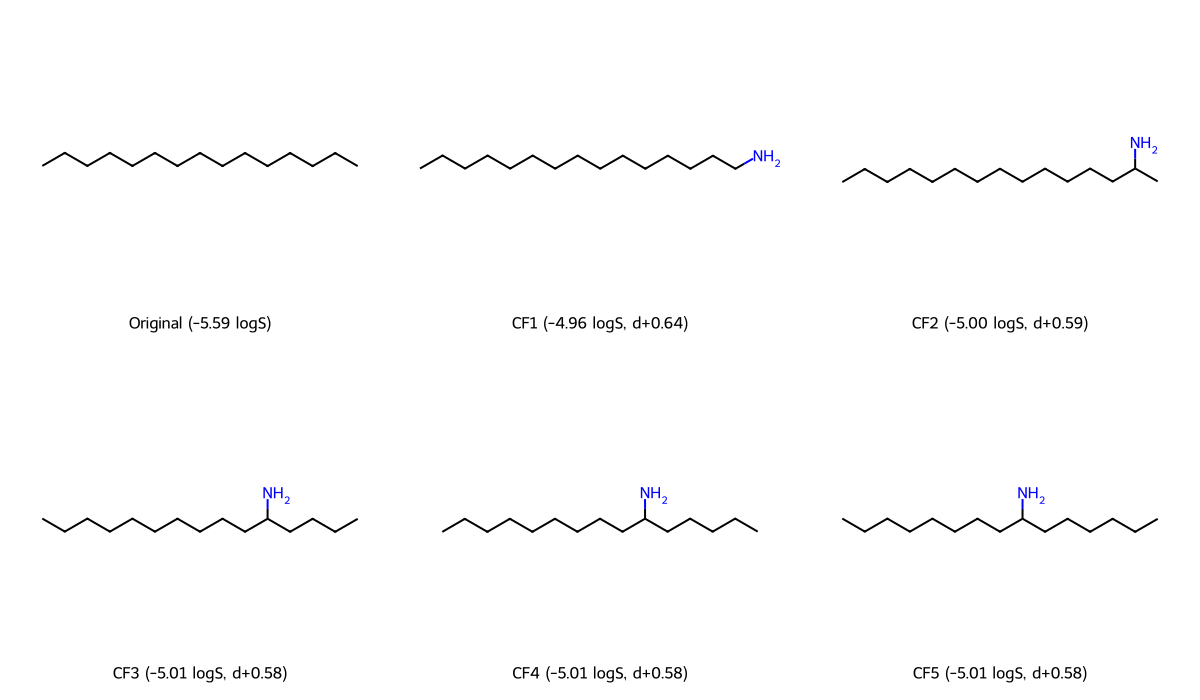


Summary Statistics:
  Counterfactuals: 10
  |delta logS| range: 0.583 to 0.638
  Average |delta|: 0.590 +/- 0.016 logS
  Modification types: {'add_node': 10}

VGD Exhaustive Counterfactual Analysis -- Decrease (less soluble)

Top Counterfactuals (by prediction-change magnitude):
----------------------------------------------------------------------

Counterfactual 1:
  SMILES: C(CCCCCCCCCCCCCC)#[SH]
  Solubility: -5.593 -> -5.919 logS (delta -0.326)
  Modification type: add_node
  Formula: C15H30S

Counterfactual 2:
  SMILES: C(CCCCCCCCCCCCCC)#C
  Solubility: -5.593 -> -5.873 logS (delta -0.280)
  Modification type: add_node
  Formula: C16H30

Counterfactual 3:
  SMILES: CCCCCCCCCCCCCCCCl
  Solubility: -5.593 -> -5.863 logS (delta -0.269)
  Modification type: add_node
  Formula: C15H31Cl

Counterfactual 4:
  SMILES: CCCCCCCCCCCCCCCC
  Solubility: -5.593 -> -5.860 logS (delta -0.266)
  Modification type: add_node
  Formula: C16H34

Counterfactual 5:
  SMILES: CCCCCCCCCCCCCC(C)Cl
  Solu

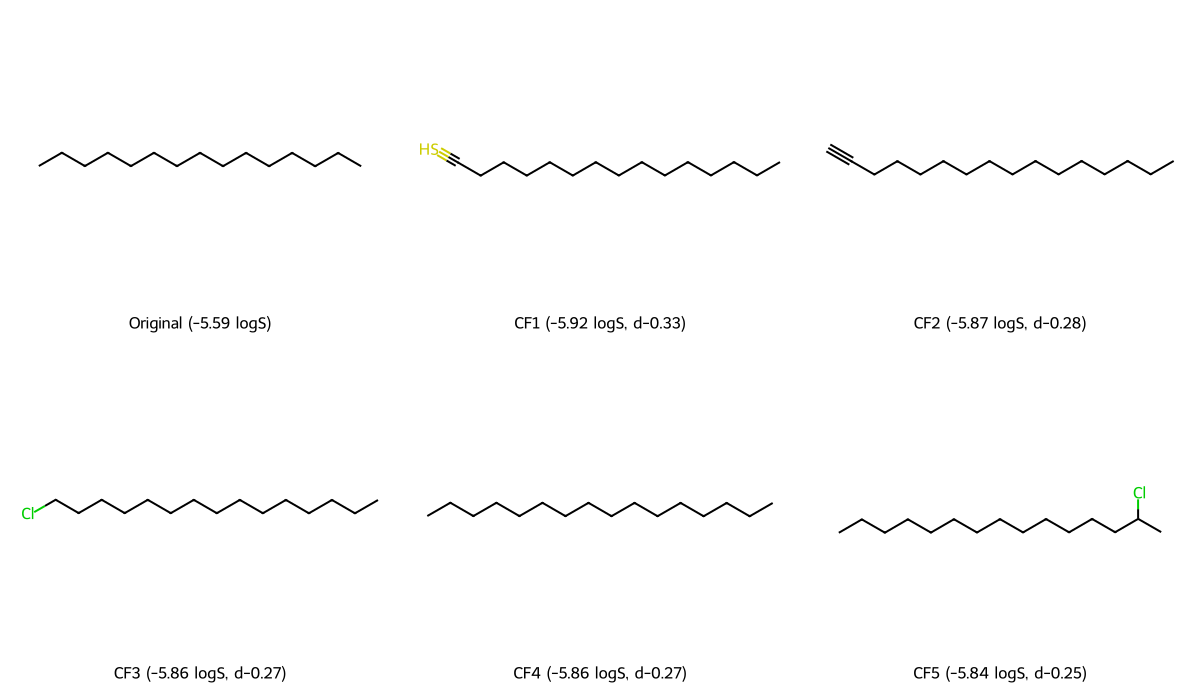


Summary Statistics:
  Counterfactuals: 10
  |delta logS| range: 0.202 to 0.326
  Average |delta|: 0.246 +/- 0.037 logS
  Modification types: {'add_node': 10}


In [20]:
# --- Visualization Helper for VGD Counterfactuals ---

def display_vgd_counterfactual_grid(original_smiles: str,
                                     original_pred: float,
                                     counterfactuals: list[dict],
                                     max_display: int = 5,
                                     mol_per_row: int = 3,
                                     img_size: tuple = (400, 350)) -> None:
    """
    Display a grid of molecular structures for VGD-style counterfactuals (dict format).

    :param original_smiles: SMILES string of the original molecule.
    :param original_pred: Predicted value for the original molecule.
    :param counterfactuals: List of counterfactual dictionaries with 'smiles' and 'prediction' keys.
    :param max_display: Maximum number of counterfactuals to display.
    :param mol_per_row: Number of molecules per row in the grid.
    :param img_size: Size of each molecule image as (width, height).
    """
    original_mol = Chem.MolFromSmiles(original_smiles)

    mols_for_grid = [original_mol] if original_mol else []
    legends = [f'Original ({original_pred:.2f} logS)'] if original_mol else []

    for i, cf in enumerate(counterfactuals[:max_display], 1):
        cf_mol = Chem.MolFromSmiles(cf['smiles'])
        if cf_mol:
            cf_change = cf['prediction'] - original_pred
            mols_for_grid.append(cf_mol)
            legends.append(f'CF{i} ({cf["prediction"]:.2f} logS, d{cf_change:+.2f})')

    if mols_for_grid:
        img = Draw.MolsToGridImage(
            mols_for_grid,
            molsPerRow=mol_per_row,
            subImgSize=img_size,
            legends=legends
        )
        display(img)


# --- Display VGD Results (per direction) ---

original_mol = Chem.MolFromSmiles(TARGET_SMILES)

print('Original Molecule:')
print(f'  SMILES: {TARGET_SMILES}')
print(f'  Predicted solubility: {selected_prediction:.3f} logS')
if original_mol:
    print(f'  Formula: {Chem.rdMolDescriptors.CalcMolFormula(original_mol)}')
    print(f'  Atoms: {original_mol.GetNumAtoms()} | Bonds: {original_mol.GetNumBonds()}')

vgd_directions = [
    ('Increase (more soluble)', vgd_increase),
    ('Decrease (less soluble)', vgd_decrease),
]

for direction_name, cf_list in vgd_directions:
    print('\n' + '=' * 70)
    print(f'VGD Exhaustive Counterfactual Analysis -- {direction_name}')
    print('=' * 70)

    if not cf_list:
        print(f'No "{direction_name}" counterfactuals found for this molecule.')
        continue

    print(f'\nTop Counterfactuals (by prediction-change magnitude):')
    print('-' * 70)

    for i, cf in enumerate(cf_list[:5], 1):
        cf_change = cf['change']

        print(f'\nCounterfactual {i}:')
        print(f'  SMILES: {cf["smiles"]}')
        print(f'  Solubility: {selected_prediction:.3f} -> {cf["prediction"]:.3f} logS (delta {cf_change:+.3f})')
        print(f'  Modification type: {cf["modification_type"]}')

        cf_mol = Chem.MolFromSmiles(cf['smiles'])
        if cf_mol:
            print(f'  Formula: {Chem.rdMolDescriptors.CalcMolFormula(cf_mol)}')

    # Display molecular structures
    print('\nMolecular Structures:')
    display_vgd_counterfactual_grid(TARGET_SMILES, selected_prediction, cf_list)

    # Summary statistics
    distances = [cf['distance'] for cf in cf_list]
    mod_types = {}
    for cf in cf_list:
        t = cf['modification_type']
        mod_types[t] = mod_types.get(t, 0) + 1

    print('\nSummary Statistics:')
    print(f'  Counterfactuals: {len(cf_list)}')
    print(f'  |delta logS| range: {min(distances):.3f} to {max(distances):.3f}')
    print(f'  Average |delta|: {np.mean(distances):.3f} +/- {np.std(distances):.3f} logS')
    print(f'  Modification types: {mod_types}')

**Interpreting Exhaustive Enumeration Results.** Unlike MMACE, the exhaustive approach guarantees finding the *optimal* counterfactual within the specified edit distance. The counterfactuals are ranked by the *magnitude* of prediction change rather than similarity. Key aspects to examine:

- **Modification type**: Each counterfactual represents a single, specific molecular edit (e.g., an atom addition or a bond removal).
- **Prediction change**: The largest changes appear first, revealing which single modifications have the greatest impact on the model's predictions.
- **Chemical interpretability**: Since each counterfactual differs by exactly one edit, the structure-property relationship is immediately clear &mdash; "adding a nitrogen atom here increases predicted solubility by X logS units."

This approach is particularly valuable for lead optimization, where medicinal chemists need to know the single most impactful modification to make.

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 3.3** $\cdot$ By default, `get_neighborhood` enumerates only atom additions and bond removals (`use_bond_additions=False`). Try calling it with `use_bond_additions=True`, or extend its `atom_valence_map` to include additional element types, and observe how the set of generated counterfactuals changes. Which new kinds of structural modifications appear, and what do they reveal about the model's behavior?

</div>

### Comparing MMACE vs Exhaustive Enumeration

Now let's directly compare the counterfactuals generated by both methods. Because both methods now produce *directional* counterfactuals, we compare them **direction by direction**: the best solubility-*increasing* counterfactual from MMACE against the best solubility-*increasing* counterfactual from VGD, and likewise for the solubility-*decreasing* direction. This keeps the comparison fair &mdash; "more soluble" is compared with "more soluble" and "less soluble" with "less soluble" &mdash; while still highlighting the fundamental trade-off between sampling-based and exhaustive approaches.

Comparison: MMACE (Sampling) vs VGD (Exhaustive) -- per direction

######################################################################
Direction: Increase (more soluble)
######################################################################

MMACE (STONED sampling) -- best by similarity:
  Counterfactual: C(CCCCCCCCCCCC)C
  Prediction change: delta +0.491 logS
  Similarity: 0.930

VGD (Exhaustive enumeration) -- best by magnitude:
  Counterfactual: C(CCCCCCCCCCCCCC)N
  Prediction change: delta +0.638 logS
  Modification type: add_node

Side-by-Side Comparison:


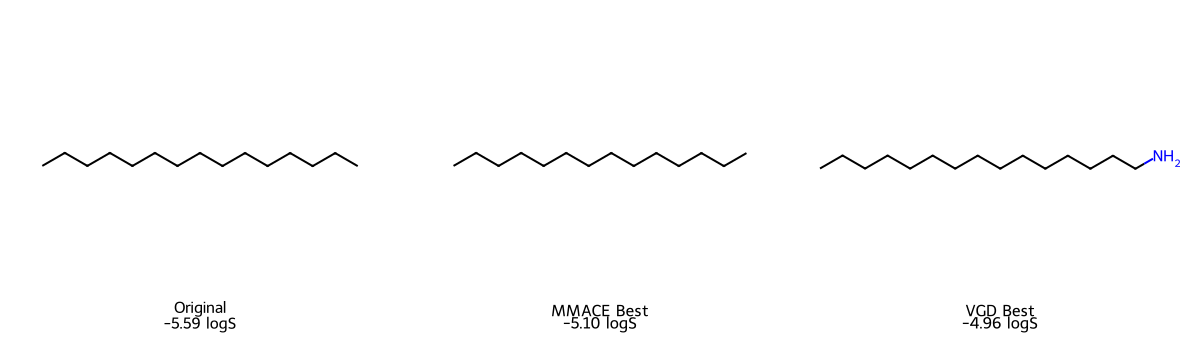


Method Comparison Summary:
----------------------------------------------------------------------
Method                    Approach             Best d logS     Guarantee
----------------------------------------------------------------------
MMACE                     Random sampling      +0.491           Probabilistic
VGD                       Exhaustive enum.     +0.638           Optimal in 1-edit

######################################################################
Direction: Decrease (less soluble)
######################################################################

MMACE (STONED sampling) -- best by similarity:
  Counterfactual: ICCCCCCCCCCCCCC
  Prediction change: delta -0.762 logS
  Similarity: 0.792

VGD (Exhaustive enumeration) -- best by magnitude:
  Counterfactual: C(CCCCCCCCCCCCCC)#[SH]
  Prediction change: delta -0.326 logS
  Modification type: add_node

Side-by-Side Comparison:


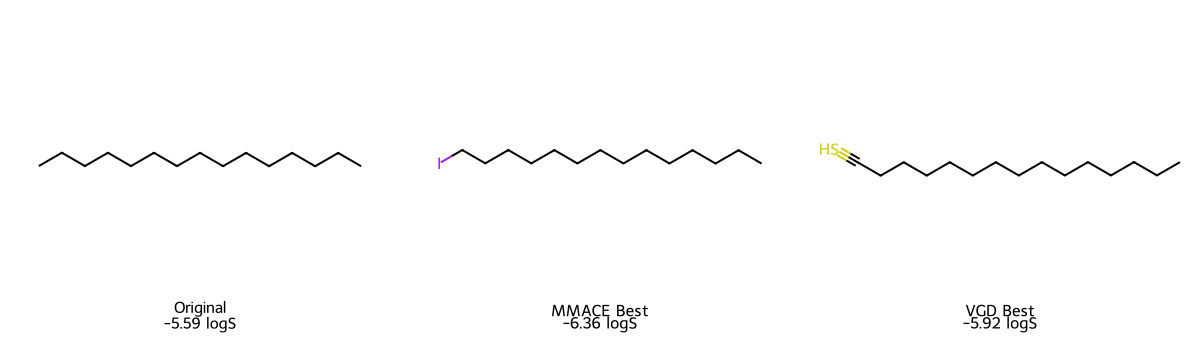


Method Comparison Summary:
----------------------------------------------------------------------
Method                    Approach             Best d logS     Guarantee
----------------------------------------------------------------------
MMACE                     Random sampling      -0.762           Probabilistic
VGD                       Exhaustive enum.     -0.326           Optimal in 1-edit


In [21]:
# --- Compare MMACE and VGD counterfactuals, direction by direction ---
# For each direction we pair the best MMACE counterfactual (most similar) against the best
# VGD counterfactual (largest prediction change), so that "more soluble" is compared with
# "more soluble" and "less soluble" with "less soluble".

original_mol = Chem.MolFromSmiles(TARGET_SMILES)

comparison_directions = [
    ('Increase (more soluble)', mmace_increase, vgd_increase),
    ('Decrease (less soluble)', mmace_decrease, vgd_decrease),
]

print('=' * 70)
print('Comparison: MMACE (Sampling) vs VGD (Exhaustive) -- per direction')
print('=' * 70)

for direction_name, mmace_list, vgd_list in comparison_directions:
    print('\n' + '#' * 70)
    print(f'Direction: {direction_name}')
    print('#' * 70)

    mmace_best = mmace_list[0] if mmace_list else None
    vgd_best = vgd_list[0] if vgd_list else None

    if mmace_best is not None:
        print(f'\nMMACE (STONED sampling) -- best by similarity:')
        print(f'  Counterfactual: {mmace_best.smiles}')
        print(f'  Prediction change: delta {mmace_best.prediction_change:+.3f} logS')
        print(f'  Similarity: {mmace_best.similarity:.3f}')
    else:
        print('\nMMACE: no counterfactual in this direction.')

    if vgd_best is not None:
        print(f'\nVGD (Exhaustive enumeration) -- best by magnitude:')
        print(f'  Counterfactual: {vgd_best["smiles"]}')
        print(f'  Prediction change: delta {vgd_best["change"]:+.3f} logS')
        print(f'  Modification type: {vgd_best["modification_type"]}')
    else:
        print('\nVGD: no counterfactual in this direction.')

    # Side-by-side visual comparison: original, best MMACE, best VGD
    comparison_mols = []
    comparison_legends = []

    if original_mol:
        comparison_mols.append(original_mol)
        comparison_legends.append(f'Original\n{selected_prediction:.2f} logS')

    if mmace_best is not None:
        mmace_mol = Chem.MolFromSmiles(mmace_best.smiles)
        if mmace_mol:
            comparison_mols.append(mmace_mol)
            comparison_legends.append(f'MMACE Best\n{mmace_best.yhat:.2f} logS')

    if vgd_best is not None:
        vgd_mol = Chem.MolFromSmiles(vgd_best['smiles'])
        if vgd_mol:
            comparison_mols.append(vgd_mol)
            comparison_legends.append(f'VGD Best\n{vgd_best["prediction"]:.2f} logS')

    if len(comparison_mols) > 1:
        print('\nSide-by-Side Comparison:')
        img = Draw.MolsToGridImage(
            comparison_mols,
            molsPerRow=3,
            subImgSize=(400, 350),
            legends=comparison_legends
        )
        display(img)

    # Summary table for this direction
    print('\nMethod Comparison Summary:')
    print('-' * 70)
    print(f'{"Method":<25} {"Approach":<20} {"Best d logS":<15} {"Guarantee"}')
    print('-' * 70)
    if mmace_best is not None:
        print(f'{"MMACE":<25} {"Random sampling":<20} {mmace_best.prediction_change:+.3f}{"":>10} {"Probabilistic"}')
    if vgd_best is not None:
        print(f'{"VGD":<25} {"Exhaustive enum.":<20} {vgd_best["change"]:+.3f}{"":>10} {"Optimal in 1-edit"}')

**Method Comparison Insights.** The side-by-side comparison illustrates the fundamental difference in search strategy between the two approaches. MMACE explores chemical space broadly through random sampling, generating diverse molecular variants that may differ from the original by multiple modifications and ranking results by structural similarity. The exhaustive enumeration approach instead enforces strict locality, considering only molecules that differ by exactly one edit and ranking results by the magnitude of prediction change. As a result, MMACE may discover counterfactuals requiring coordinated changes across multiple positions, while exhaustive enumeration identifies the single most impactful minimal modification. Despite these differences, both methods often highlight similar structural features as relevant to the predicted property &mdash; the two perspectives can be seen as complementary views on the structure-property relationships learned by the model.

## **3.4** $\cdot$ 🔬 Discussion and Limitations

Counterfactual explanations offer a distinct perspective on model behavior by identifying molecular modifications that would change predictions, rather than highlighting important substructures. This actionable framing makes them appealing for molecular design applications, but several limitations should be considered.

**Counterfactuals Explain the Model, Not the Chemistry.** A counterfactual explanation reveals what structural change would alter the *model's prediction* &mdash; not necessarily what would change the *actual molecular property*. This distinction is critical. If the model has learned spurious correlations or relies on features that happen to correlate with solubility in the training data but lack causal relevance, the suggested modifications may be chemically meaningless or even counterproductive. A counterfactual stating that "adding a hydroxyl group here would increase predicted solubility by 1.5 logS" should be understood as a statement about the model's learned decision boundary, not as a guarantee about real-world molecular behavior. The reliability of counterfactual suggestions is therefore bounded by the reliability of the underlying model.

**Synthesizability and Actionability.** Both methods presented in this tutorial generate chemically *valid* molecules &mdash; structures that satisfy valence rules and pass RDKit sanitization. However, chemical validity does not imply *synthesizability*. A suggested counterfactual may require synthetic routes that are prohibitively expensive, involve unstable intermediates, or simply do not exist with current chemistry. Neither MMACE nor the exhaustive enumeration approach considers synthetic accessibility, reagent availability, or the practical feasibility of the proposed modifications. When using counterfactuals to guide molecular design decisions, additional filtering for synthesizability &mdash; whether through computational scoring functions or expert assessment &mdash; is essential to bridge the gap between algorithmically generated suggestions and actionable laboratory targets.

**Practical Implications.** The two counterfactual methods presented in this tutorial offer complementary strengths that should inform method selection. The exhaustive enumeration approach guarantees finding the optimal counterfactual within the specified edit distance, making it well-suited for smaller molecules where the neighborhood remains computationally tractable and where identifying the provably minimal structural change is valuable. For larger molecules, where exhaustive enumeration becomes impractical, MMACE provides a scalable alternative through stochastic sampling of chemical space &mdash; though without guarantees of finding the smallest possible modification. Regardless of method choice, counterfactual explanations should be treated as tools for exploration rather than definitive design recommendations. Multiple valid counterfactuals typically exist for any given molecule, and different counterfactuals may suggest different or even contradictory modifications. This multiplicity reflects the complexity of the model's decision landscape and can be leveraged to explore diverse regions of chemical space. However, it also means that no single counterfactual should be interpreted as *the* answer &mdash; rather, patterns across multiple counterfactuals, combined with domain expertise, provide the most reliable basis for decision-making.

## **References**

**Datasets**

- Sorkun, M. C., Khetan, A., & Er, S. (2019). AqSolDB, a curated reference set of aqueous solubility and 2D descriptors for a diverse set of compounds. *Scientific Data*, 6(1), 143. https://doi.org/10.1038/s41597-019-0151-1

**Methods**

- Wellawatte, G. P., Seshadri, A., & White, A. D. (2022). Model agnostic generation of counterfactual explanations for molecules. *Chemical Science*, 13, 3697–3705. https://doi.org/10.1039/D1SC05259D | [GitHub](https://github.com/ur-whitelab/exmol)

- Teufel, J., Leinweber, A., & Friederich, P. (2025). Improving counterfactual truthfulness for molecular property prediction through uncertainty quantification. In *Explainable Artificial Intelligence (xAI 2025)*, Communications in Computer and Information Science, vol. 2580. Springer. https://link.springer.com/chapter/10.1007/978-3-032-08333-3_15 | [GitHub](https://github.com/the16thpythonist/vgd_counterfactuals)

**Software**

- Landrum, G. et al. (2024). RDKit: Open-source cheminformatics software. https://www.rdkit.org

- Fey, M., & Lenssen, J. E. (2019). Fast graph representation learning with PyTorch Geometric. In *ICLR Workshop on Representation Learning on Graphs and Manifolds*. https://pytorch-geometric.readthedocs.io